# Modélisation : Qui utilise mon appli ?

Suite de `exploration_dataset.ipynb` : construction des features, comparaison de modèles en validation croisée,
puis génération du fichier de soumission.

**Métrique du concours** : score F1 moyen. On suit le **F1 macro** (chaque utilisateur pèse autant) et l'accuracy,
en validation croisée stratifiée à **K = 4** (certains utilisateurs n'ont que 4 sessions).

**Prérequis** : `pip install pandas matplotlib scikit-learn`, données dans `qui-utilise-mon-appli-v-2026-2027-groupe-2/`.

In [1]:
import gzip
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC


DATA_DIR = Path("qui-utilise-mon-appli-v-2026-2027-groupe-2")

RE_TEMPS = re.compile(r"^t(\d+)$")
RE_TEMPS_COLLE = re.compile(r"^(.*\))(t\d+)$")
RE_ACTION = re.compile(
    r"^(?P<type>[^(<$]+?)"
    r"(?:\((?P<ecran>.*)\))?"
    r"(?:<(?P<conf>[^>]*)>)?"
    r"(?:\$(?P<chaine>[^$]*)\$)?"
    r"(?P<modif>1)?$"
)

## 1. Lecture des données

Même lecture que dans le notebook d'exploration : gzip ligne par ligne, apostrophe typographique normalisée,
marqueur `tXX` collé à une action séparé.

In [2]:
def nettoyer(tokens: list[str]) -> list[str]:
    propres = []
    for tok in tokens:
        tok = tok.replace("’", "'")
        colle = RE_TEMPS_COLLE.match(tok)
        propres.extend(colle.groups() if colle else [tok])
    return propres


def lire_sessions(nom_fichier: str, avec_util: bool) -> pd.DataFrame:
    sessions = []
    with gzip.open(DATA_DIR / nom_fichier, "rt", encoding="utf-8") as f:
        for ligne in f:
            champs = ligne.rstrip("\n").split(",")
            session = {"util": champs.pop(0)} if avec_util else {}
            session["navigateur"] = champs.pop(0)
            session["tokens"] = nettoyer(champs)
            sessions.append(session)
    return pd.DataFrame(sessions)


train = lire_sessions("train.csv.GZ", avec_util=True)
test = lire_sessions("test.csv.GZ", avec_util=False)
print(f"train : {len(train)} sessions | test : {len(test)} sessions")

train : 3279 sessions | test : 324 sessions


## 2. Construction des features

Chaque session est transformée en deux représentations complémentaires.

**Un « document » de mots**, vectorisé ensuite en TF-IDF. Chaque action produit plusieurs mots préfixés :

| Préfixe | Contenu | Intuition |
| --- | --- | --- |
| `T=` | type d'action (suffixe `#M` en mode modification) | habitudes d'interaction |
| `E=` | écran visité | modules du logiciel que l'utilisateur teste |
| `C=` | conf écran | profil / métier |
| `H=` | chaîne de la fiche (`VT`, `GP`...) | module dont le testeur s'occupe |
| `ET=` | écran courant + type d'action | ce que l'utilisateur fait sur chaque écran |
| `B=` | bigramme de types d'actions consécutifs | enchaînements typiques |

**Des features numériques de rythme** : nombre d'actions, durée, vitesse, part de fenêtres de 5 s inactives,
irrégularité du rythme, part d'actions en modification.

Le **navigateur** est ajouté en one-hot.

In [3]:
def vers_document(tokens: list[str]) -> str:
    """Transforme une session en suite de mots préfixés pour le TF-IDF."""
    mots, ecran, precedent = [], None, None
    for tok in tokens:
        if RE_TEMPS.match(tok):
            continue
        a = RE_ACTION.match(tok).groupdict()
        type_ = a["type"].strip().replace(" ", "_")
        if a["ecran"]:
            ecran = a["ecran"].replace(" ", "_")
            mots.append("E=" + ecran)
        if a["conf"]:
            mots.append("C=" + a["conf"].replace(" ", "_"))
        if a["chaine"]:
            mots.append("H=" + a["chaine"])
        mots.append("T=" + type_ + ("#M" if a["modif"] else ""))
        if ecran:
            mots.append("ET=" + ecran.split(".")[-1] + "|" + type_)
        if precedent:
            mots.append("B=" + precedent + ">" + type_)
        precedent = type_
    return " ".join(mots)


def features_rythme(tokens: list[str]) -> dict:
    """Features numériques sur le rythme de la session."""
    par_fenetre, courant, duree, nb_modif = [], 0, 0, 0
    for tok in tokens:
        if m := RE_TEMPS.match(tok):
            par_fenetre.append(courant)
            courant, duree = 0, int(m.group(1))
        else:
            courant += 1
            nb_modif += tok.endswith("1")
    par_fenetre = np.array(par_fenetre or [0])
    nb_actions = sum(not RE_TEMPS.match(t) for t in tokens)
    return {
        "log_nb_actions": np.log1p(nb_actions),
        "log_duree": np.log1p(duree),
        "actions_par_s": nb_actions / (duree + 5),
        "part_inactif": (par_fenetre == 0).mean(),
        "std_par_fenetre": par_fenetre.std(),
        "part_modif": nb_modif / max(nb_actions, 1),
    }


def construire(df: pd.DataFrame) -> pd.DataFrame:
    rythme = pd.DataFrame([features_rythme(ts) for ts in df["tokens"]], index=df.index)
    return pd.concat([df[["navigateur"]], df["tokens"].map(vers_document).rename("document"), rythme], axis=1)


COLS_RYTHME = list(features_rythme([]).keys())
X_train, X_test = construire(train), construire(test)
X_train.head()

,navigateur,document,log_nb_actions,log_duree,actions_par_s,part_inactif,std_par_fenetre,part_modif
0,Firefox,E=infologic.core.accueil.AccueilController T=C...,7.830028,7.974533,0.863918,0.0,3.663269,0.001591
1,Google Chrome,E=infologic.core.gui.controllers.BlankControll...,4.510860,5.442418,0.382979,0.0,1.128761,0.288889
2,Microsoft Edge,E=infologic.core.gui.controllers.BlankControll...,6.411818,6.621406,0.805298,0.0,3.752118,0.082237
3,Firefox,E=infologic.core.gui.controllers.nested.InputF...,6.787845,7.276556,0.611034,0.0,2.859145,0.072235
4,Google Chrome,E=infologic.acti.modules.AT_ACTIVITES.comptere...,5.159055,5.620401,0.617857,0.0,2.771682,0.011561


### Valeurs aberrantes

On retire du train les 3 sessions de moins de 5 actions (repérées dans l'exploration) : elles ne contiennent
pratiquement aucune information sur l'utilisateur. Les sessions très longues sont gardées : le TF-IDF et les
features en log ou en proportion neutralisent l'effet de la longueur.

In [4]:
nb_actions = np.expm1(X_train["log_nb_actions"]).round()
garde = nb_actions >= 5
print(f"Sessions retirées : {(~garde).sum()}")
X_train, y_train = X_train[garde], train.loc[garde, "util"].to_numpy()

Sessions retirées : 3


### Statistiques sur les features de rythme

Distribution de trois features de rythme pour quelques utilisateurs ayant beaucoup de sessions : si les boîtes se
chevauchent peu, la feature aide à les distinguer.

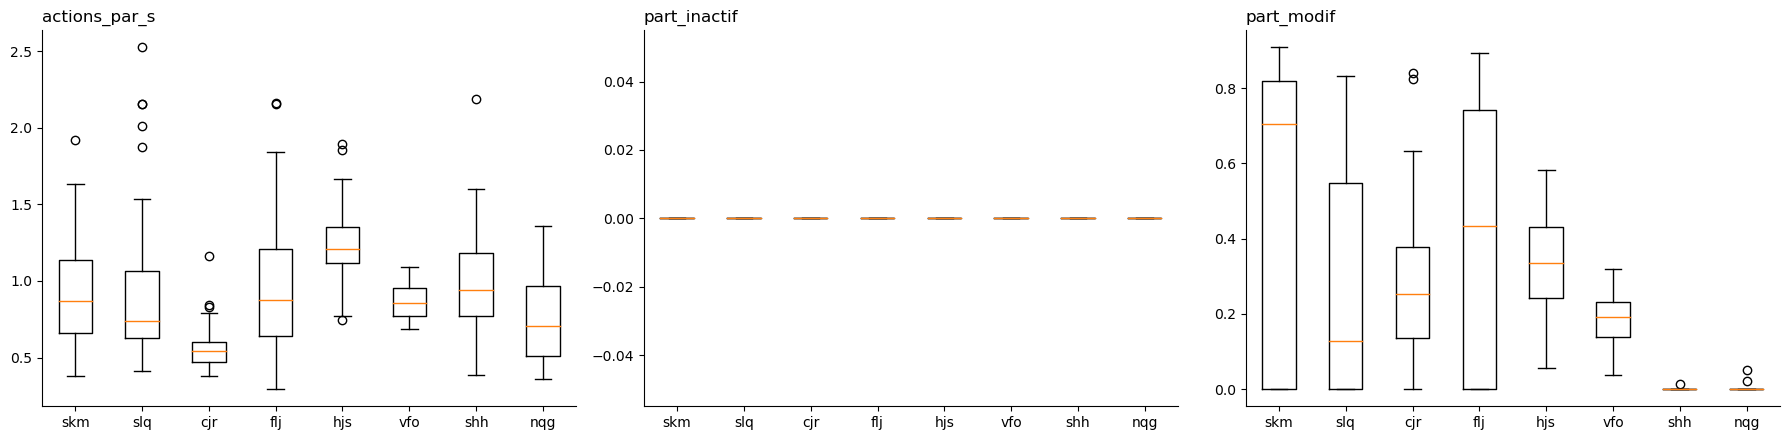

In [5]:
top_utils = pd.Series(y_train).value_counts().index[:8]
masque = np.isin(y_train, top_utils)
fig, axs = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, col in zip(axs, ["actions_par_s", "part_inactif", "part_modif"]):
    donnees = [X_train.loc[masque, col][y_train[masque] == u] for u in top_utils]
    ax.boxplot(donnees, labels=top_utils)
    ax.set_title(col, loc="left")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Comparaison de modèles

Toutes les transformations (TF-IDF, normalisation, one-hot) sont dans un `Pipeline`, réajusté à chaque pli :
aucune information du pli de validation ne fuit dans l'entraînement.

In [6]:
def preprocesseur(texte=True, rythme=True, navigateur=True):
    blocs = []
    if texte:
        blocs.append(("texte", TfidfVectorizer(token_pattern=r"\S+", lowercase=False,
                                               sublinear_tf=True, min_df=2), "document"))
    if rythme:
        blocs.append(("rythme", StandardScaler(), COLS_RYTHME))
    if navigateur:
        blocs.append(("navigateur", OneHotEncoder(handle_unknown="ignore"), ["navigateur"]))
    # Le poids réduit sur le rythme évite qu'il écrase le TF-IDF (vecteurs de norme 1)
    return ColumnTransformer(blocs, transformer_weights={"rythme": 0.3})


CV = StratifiedKFold(n_splits=4, shuffle=True, random_state=0)


def evaluer(modele, X=X_train, y=y_train, **prepro) -> dict:
    pipe = make_pipeline(preprocesseur(**prepro), modele)
    r = cross_validate(pipe, X, y, cv=CV, scoring=["accuracy", "f1_macro"], n_jobs=-1)
    return {"accuracy": r["test_accuracy"].mean(), "f1_macro": r["test_f1_macro"].mean()}


modeles = {
    "Régression logistique": LogisticRegression(C=20, max_iter=2000, class_weight="balanced"),
    "SVM linéaire": LinearSVC(C=1, dual=True, max_iter=10000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=0),
}
resultats = pd.DataFrame({nom: evaluer(m) for nom, m in modeles.items()}).T
resultats.sort_values("f1_macro", ascending=False).round(3)

,accuracy,f1_macro
SVM linéaire,0.962,0.957
Régression logistique,0.942,0.934
Random Forest,0.937,0.914


### Réglage de C pour le SVM linéaire

C contrôle la régularisation : petit C = modèle plus contraint (plus parcimonieux dans ses poids), grand C = modèle
qui colle davantage au train.

In [7]:
grille_C = [0.1, 0.3, 1, 3, 10]
reglage = pd.DataFrame({C: evaluer(LinearSVC(C=C, dual=True, max_iter=10000, class_weight="balanced")) for C in grille_C}).T.rename_axis("C")
reglage.round(3)

,accuracy,f1_macro
C,,
0.1,0.937,0.935
0.3,0.953,0.951
1.0,0.962,0.957
3.0,0.964,0.960
10.0,0.964,0.960


### Quels groupes de features comptent ?

Ablation : on retire un groupe à la fois et on mesure la perte de F1 macro.

In [8]:
meilleur_C = reglage["f1_macro"].idxmax()
svm = LinearSVC(C=meilleur_C, dual=True, max_iter=10000, class_weight="balanced")
ablation = pd.DataFrame({
    "tout": evaluer(svm),
    "sans texte (TF-IDF)": evaluer(svm, texte=False),
    "sans rythme": evaluer(svm, rythme=False),
    "sans navigateur": evaluer(svm, navigateur=False),
}).T
ablation.round(3)

,accuracy,f1_macro
tout,0.964,0.960
sans texte (TF-IDF),0.088,0.038
sans rythme,0.965,0.960
sans navigateur,0.947,0.935


Ce qu'on observe (validation croisée stratifiée, 4 plis) :

- Le **SVM linéaire sur TF-IDF** est le meilleur modèle (~96 % d'accuracy, F1 macro ~0,96), devant la régression
  logistique et la Random Forest. Classique sur des données textuelles creuses et de grande dimension.
- Au-delà de C = 3, le score plafonne : peu de risque à régler C finement.
- **Le TF-IDF porte presque tout le signal** : sans lui, le F1 macro s'effondre. Les écrans, confs et chaînes
  identifient le périmètre de chaque testeur.
- Le **navigateur** apporte environ 2 points de F1 macro (il est constant par utilisateur).
- Les **features de rythme** n'apportent rien en plus du TF-IDF dans ce modèle linéaire.

## 4. Modèle final et soumission

On réentraîne le meilleur modèle sur tout le train, puis on prédit le test. Format attendu : `RowId` (à partir de 1,
dans l'ordre du fichier test) et `prediction` (le trigramme).

In [9]:
modele_final = make_pipeline(preprocesseur(), LinearSVC(C=meilleur_C, dual=True, max_iter=10000, class_weight="balanced"))
modele_final.fit(X_train, y_train)
predictions = modele_final.predict(X_test)

soumission = pd.DataFrame({"RowId": np.arange(1, len(predictions) + 1), "prediction": predictions})
soumission.to_csv("submission.csv", index=False)
print(f"C retenu : {meilleur_C} | {len(soumission)} prédictions, {soumission['prediction'].nunique()} utilisateurs distincts")
soumission.head()

C retenu : 3.0 | 324 prédictions, 224 utilisateurs distincts


,RowId,prediction
0,1,hzx
1,2,prb
2,3,jmq
3,4,psg
4,5,cvw


## 5. Pistes suivantes

- Interprétabilité (questions de la consigne) : importance des features de la Random Forest, coefficients du SVM
  par utilisateur, confiance des prédictions (`predict_proba` de la régression logistique).
- Tester un MLP et XGBoost, et des n-grammes plus longs.
- Analyser les erreurs : quels utilisateurs sont confondus entre eux ?